# Customer Segmentation of Olist E-commerce Customers

### RFM analysis + K-Means clustering on the Brazilian E-Commerce Public Dataset by Olist

Data: approximately 100,000 real orders placed on Olist, a Brazilian e-commerce marketplace, between 2016 and 2018  
Techniques: multi-table joins · RFM feature engineering · log transformation and scaling · K-Means clustering · elbow, silhouette and Davies–Bouldin analysis · cluster stability check · segment profiling

---

## 1. Problem statement

Olist connects small Brazilian sellers with customers through a large online marketplace. It manages the storefront, payments, and logistics, while the customer completes the purchase in a single checkout experience. Olist has released anonymised data for around 100,000 orders, including purchase value, order dates, delivery times, and customer reviews.

The business challenge is to understand how customers differ in their buying behaviour and to identify meaningful segments that can be targeted with different marketing actions.

### Objective

Group Olist customers into distinct behavioural segments, explain the characteristics of each segment in business terms, and recommend a tailored marketing strategy for each.

### Approach

1. Join the orders, customers, and payments tables, and retain only delivered orders.
2. Build three customer-level behavioural features using RFM:
   - Recency: number of days since the customer’s last purchase
   - Frequency: number of orders placed
   - Monetary: total amount spent by the customer
3. Apply a log transformation and standardise the features before clustering.
4. Evaluate the number of clusters using methods such as the elbow method, silhouette score, and Davies–Bouldin index.
5. Fit a K-Means model, interpret the resulting clusters, and assess cluster stability.
6. Profile each segment using additional information such as delivery time, review behaviour, product categories, and payment preferences.
7. Translate the findings into practical marketing recommendations for Olist.

---

## 2. Business context

Online marketplaces often face the challenge of serving highly diverse customer groups with very different purchasing habits. Some customers buy frequently and spend heavily, while others purchase only occasionally or become inactive over time. Identifying these differences allows businesses to move from a generic strategy to targeted customer engagement.

For Olist, customer segmentation can support:
- retention campaigns for low-frequency customers,
- loyalty rewards for high-value repeat buyers,
- win-back strategies for inactive customers,
- personalised offers based on spending and product preferences.

---

## 3. Dataset

The dataset contains transaction-level information across multiple tables, including:
- orders,
- customers,
- order items,
- payments,
- reviews,
- products,
- sellers.

This makes it possible to study customer behaviour not only through purchase frequency and spend, but also through delivery performance, satisfaction signals, and product categories.

## 4. Setup

In [1]:
import sys
import warnings
from pathlib import Path
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import matplotlib.dates as mdates
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score, adjusted_rand_score

pd.set_option("display.float_format", lambda x: f"{x:,.2f}")
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.config import OUTPUT_DIR, FIGURES_DIR, RANDOM_STATE
from src.data import load_tables
from src.style import apply_style, SURFACE, INK, INK_2, MUTED, GRID, AXIS, BLUE, ORANGE, RED, SEGMENT_PALETTE
apply_style()
ACCENT = BLUE   # single-series colour
brl = lambda v, _=None: f"R${v:,.0f}"

# One fixed colour per segment, used in every chart
SEG_ORDER = ["Repeat Buyers", "Recent Buyers", "Lapsed High-Spenders", "Lapsed Low-Spenders"]
SEG_COLORS = dict(zip(SEG_ORDER, SEGMENT_PALETTE))

## 5. Load the data

Olist's data is spread across several related tables. We use six of them, plus a lookup table that translates the Portuguese product category names into English:

| Table | One row per | Used for |
|---|---|---|
| `customers` | order-level customer ID, with a `customer_unique_id` that identifies the real person | linking orders to people |
| `orders` | order | purchase date, status, delivery dates |
| `order_payments` | payment on an order (an order can have several) | how much was paid, how, and in how many instalments |
| `order_reviews` | review | satisfaction score |
| `order_items` | item in an order | product categories |
| `products` + translation | product | English category names |

In [2]:
tables = load_tables()
customers, orders, payments = tables["customers"], tables["orders"], tables["payments"]
reviews, items, products, cat_names = tables["reviews"], tables["items"], tables["products"], tables["category_names"]

pd.DataFrame({
    "table": ["customers", "orders", "payments", "reviews", "items", "products"],
    "rows": [len(t) for t in (customers, orders, payments, reviews, items, products)],
    "columns": [t.shape[1] for t in (customers, orders, payments, reviews, items, products)],
})

,table,rows,columns
0,customers,99441,5
1,orders,99441,8
2,payments,103886,5
3,reviews,100000,7
4,items,112650,6
5,products,32951,9


## 6. Data preparation

### 6.1 Which orders should be included?

Not every order is suitable for customer-level analysis. We keep only **delivered** orders. Orders that were cancelled or unavailable never became real purchases, while orders that are still in transit do not yet have reliable delivery or review data.


In [3]:
status = orders.order_status.value_counts().to_frame("orders")
status["%"] = (status.orders / len(orders) * 100).round(1)
status

,orders,%
order_status,,
delivered,96478,97.00
shipped,1107,1.10
canceled,625,0.60
unavailable,609,0.60
invoiced,314,0.30
processing,301,0.30
created,5,0.00
approved,2,0.00


### 6.2 Two customer IDs

The first thing to notice in the Olist data is that `customer_id` is not a true customer identifier. It is created **per order**, so the same person can appear multiple times if they have placed more than one purchase. The real customer identity is `customer_unique_id`, and using `customer_id` for segmentation would make almost everyone look like a one-time buyer.


In [4]:
print(f"customer_id values:        {customers.customer_id.nunique():,}")
print(f"customer_unique_id values: {customers.customer_unique_id.nunique():,}")

customer_id values:        99,441
customer_unique_id values: 96,096


### 6.3 Build a clean order table

For the analysis, we aggregate each order to a single value: the **sum of its payments**. This reflects the amount the customer actually paid, including freight, and is important because some orders are split across multiple payment methods.


In [5]:
order_value = payments.groupby("order_id").payment_value.sum().rename("order_value")

df = (orders[orders.order_status == "delivered"]
      .merge(customers[["customer_id", "customer_unique_id", "customer_state"]], on="customer_id")
      .join(order_value, on="order_id"))

print(f"Delivered orders:            {len(df):,}")
print(f"Delivered orders w/o payment: {df.order_value.isna().sum()}")
df = df.dropna(subset=["order_value"])
print(f"Orders used:                 {len(df):,}")
print(f"Customers (unique people):   {df.customer_unique_id.nunique():,}")
print(f"Total revenue:               R${df.order_value.sum():,.0f}")
print(f"Purchase dates:              {df.order_purchase_timestamp.min():%d %b %Y} → {df.order_purchase_timestamp.max():%d %b %Y}")

Delivered orders:            96,478
Delivered orders w/o payment: 1
Orders used:                 96,477
Customers (unique people):   93,357
Total revenue:               R$15,422,462
Purchase dates:              03 Oct 2016 → 29 Aug 2018


## 7. Exploratory analysis

findfont: Failed to find font weight semibold for DejaVu Sans, now using 700.


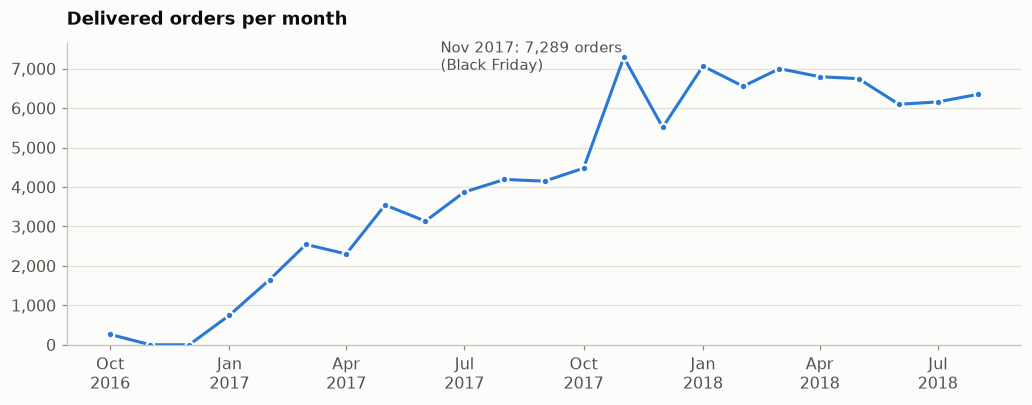

In [6]:
monthly = df.set_index("order_purchase_timestamp").resample("MS").size()

fig, ax = plt.subplots(figsize=(9.5, 3.8))
ax.plot(monthly.index, monthly.values, color=ACCENT, marker="o", markersize=5,
        markeredgecolor=SURFACE, markeredgewidth=1.5)
ax.set_title("Delivered orders per month")
ax.yaxis.set_major_formatter(mtick.StrMethodFormatter("{x:,.0f}"))
ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1, 4, 7, 10]))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b\n%Y"))
nov = pd.Timestamp("2017-11-01")
ax.annotate(f"Nov 2017: {monthly[nov]:,} orders\n(Black Friday)", (nov, monthly[nov]),
            xytext=(-120, 0), textcoords="offset points", color=INK_2, fontsize=9.5, va="center")
ax.set_ylim(0); ax.grid(axis="x", visible=False)
plt.tight_layout(); plt.show()

The business grew quickly through 2017 and then levelled off in 2018, with a clear Black Friday spike in November 2017. The data is thinner at the edges: there are very few orders in late 2016, and deliveries stop at the end of August 2018.


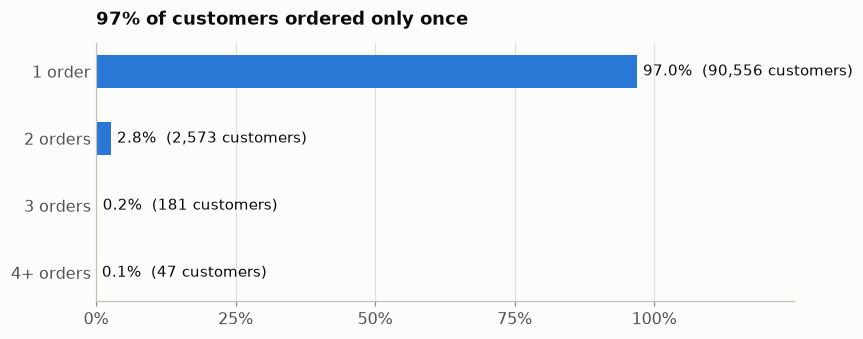

In [7]:
orders_per_customer = df.groupby("customer_unique_id").order_id.nunique()
freq_dist = orders_per_customer.clip(upper=4).value_counts().sort_index()
freq_dist.index = ["1 order", "2 orders", "3 orders", "4+ orders"]

fig, ax = plt.subplots(figsize=(8, 3.2))
pct = freq_dist / freq_dist.sum() * 100
ax.barh(pct.index[::-1], pct.values[::-1], height=0.5, color=ACCENT)
for y, (v, n) in enumerate(zip(pct.values[::-1], freq_dist.values[::-1])):
    ax.text(v + 1, y, f"{v:.1f}%  ({n:,} customers)", va="center", color=INK, fontsize=10)
ax.set_xlim(0, 125); ax.xaxis.set_major_formatter(mtick.PercentFormatter(decimals=0))
ax.set_xticks([0, 25, 50, 75, 100])
ax.set_title(f"{pct.iloc[0]:.0f}% of customers ordered only once")
ax.grid(axis="y", visible=False); ax.tick_params(axis="y", length=0)
plt.tight_layout(); plt.show()

Nearly 90% of customers bought **only once**. That fact shapes the whole project:

- **Frequency adds very little signal** for most customers, because the distribution is dominated by one-order buyers.
- The few repeat buyers stand out clearly once the features are standardised.
- The real question is not simply "who are our loyal customers?" but **"why do so few customers come back, and which ones are worth bringing back?"**

## 8. Feature engineering: RFM

We measure recency from a **snapshot date** one day after the last purchase, as if we were running this analysis on 30 August 2018.


In [8]:
snapshot_date = df.order_purchase_timestamp.max().normalize() + pd.Timedelta(days=1)
print("Snapshot date:", snapshot_date.date())

rfm = df.groupby("customer_unique_id").agg(
    Recency=("order_purchase_timestamp", lambda d: (snapshot_date - d.max()).days),
    Frequency=("order_id", "nunique"),
    Monetary=("order_value", "sum"),
)
features = ["Recency", "Frequency", "Monetary"]
print(f"Customers to segment: {len(rfm):,}")
rfm.describe().T

Snapshot date: 2018-08-30
Customers to segment: 93,357


,count,mean,std,min,25%,50%,75%,max
Recency,"93,357.00",237.47,152.59,0.00,114.00,218.00,346.00,695.00
Frequency,"93,357.00",1.03,0.21,1.00,1.00,1.00,1.00,15.00
Monetary,"93,357.00",165.20,226.31,9.59,63.06,107.78,182.56,"13,664.08"


### Transforming the features

K-Means groups observations by **distance**, so skewed features and features on different scales can distort the clustering. Monetary spend is strongly right-skewed: the highest-spending customer paid more than R$13,000, while the median is only around R$108. We apply a `log1p` transformation to reduce this skew, then standardise each feature to mean 0 and standard deviation 1 so that all three variables contribute equally.

Frequency remains highly skewed even after the log transform, because most customers have exactly one order. In this case, there is no simple transformation that fixes that structure. As a result, K-Means naturally separates repeat buyers from one-time buyers, and that distinction is actually useful for the business question we are trying to answer.


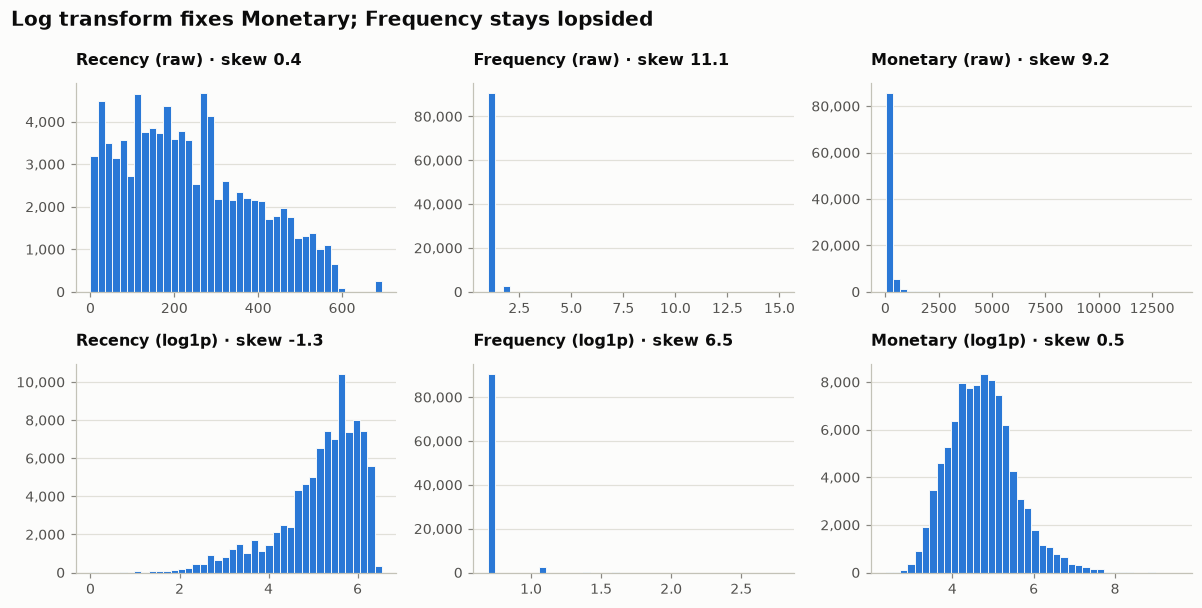

In [10]:
rfm_log = np.log1p(rfm[features])

fig, axes = plt.subplots(2, 3, figsize=(11, 5.6))
for i, col in enumerate(features):
    for row, (data, label) in enumerate([(rfm[col], "raw"), (rfm_log[col], "log1p")]):
        ax = axes[row, i]
        ax.hist(data, bins=40, color=ACCENT, edgecolor=SURFACE, linewidth=0.6)
        ax.set_title(f"{col} ({label}) · skew {data.skew():.1f}", fontsize=10.5)
        ax.grid(axis="x", visible=False); ax.tick_params(labelsize=9)
        ax.yaxis.set_major_formatter(mtick.StrMethodFormatter("{x:,.0f}"))
fig.suptitle("Log transform fixes Monetary; Frequency stays lopsided", x=0.01, ha="left",
             fontsize=13, fontweight="semibold")
plt.tight_layout(); plt.show()

scaler = StandardScaler()
X = scaler.fit_transform(rfm_log)

## 9. Choosing the number of clusters

We fit K-Means for k = 2…10 and compare:

- **Inertia** (within-cluster sum of squares). The elbow is the clearest signal here.
- **Silhouette score** (higher is better). It is calculated on a random sample of 20,000 customers, because the full score would require a 93,000 × 93,000 distance matrix.
- **Davies–Bouldin index** (lower is better).


In [11]:
k_range = range(2, 11)
results = []
for k in k_range:
    km = KMeans(n_clusters=k, n_init=10, random_state=RANDOM_STATE).fit(X)
    results.append({
        "k": k,
        "inertia": km.inertia_,
        "silhouette": silhouette_score(X, km.labels_, sample_size=20_000, random_state=RANDOM_STATE),
        "davies_bouldin": davies_bouldin_score(X, km.labels_),
    })
k_scores = pd.DataFrame(results).set_index("k")
k_scores.round(3)

,inertia,silhouette,davies_bouldin
k,,,
2,"190,211.94",0.71,0.47
3,"129,260.21",0.43,0.83
4,"82,927.16",0.40,0.76
5,"68,339.59",0.36,0.81
6,"58,450.54",0.35,0.80
7,"51,271.89",0.35,0.81
8,"45,935.01",0.35,0.84
9,"41,176.18",0.35,0.86
10,"36,791.97",0.34,0.83


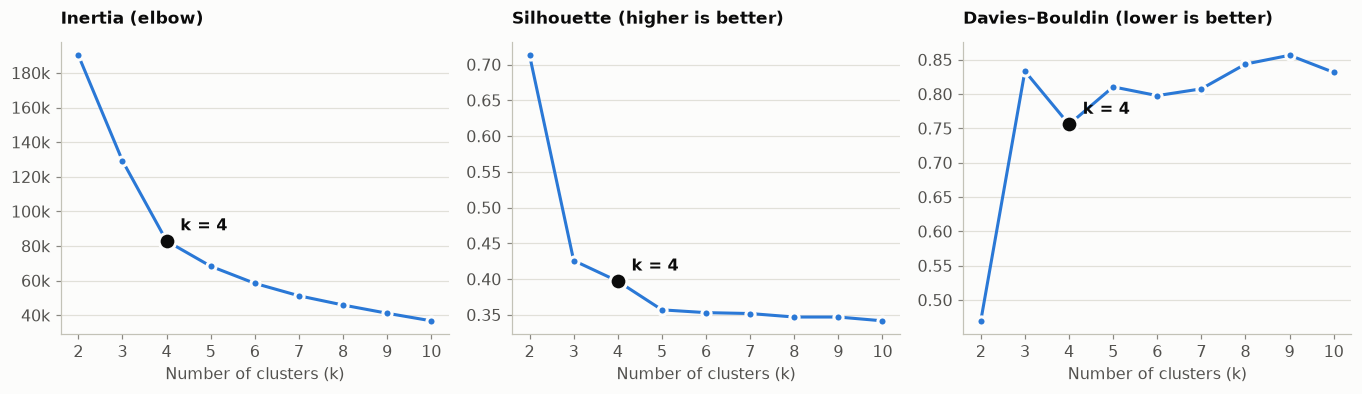

In [13]:
CHOSEN_K = 4

fig, axes = plt.subplots(1, 3, figsize=(12.5, 3.7))
panels = [("inertia", "Inertia (elbow)"), ("silhouette", "Silhouette (higher is better)"),
          ("davies_bouldin", "Davies–Bouldin (lower is better)")]
for ax, (col, title) in zip(axes, panels):
    ax.plot(k_scores.index, k_scores[col], color=ACCENT, marker="o", markersize=6,
            markeredgecolor=SURFACE, markeredgewidth=2)
    ax.plot(CHOSEN_K, k_scores.loc[CHOSEN_K, col], marker="o", markersize=11, color=INK,
            markeredgecolor=SURFACE, markeredgewidth=2, zorder=5)
    ax.annotate(f"k = {CHOSEN_K}", (CHOSEN_K, k_scores.loc[CHOSEN_K, col]), xytext=(9, 7),
                textcoords="offset points", color=INK, fontweight="semibold")
    ax.set_title(title, fontsize=11); ax.set_xlabel("Number of clusters (k)")
    ax.set_xticks(list(k_range)); ax.grid(axis="x", visible=False)
axes[0].yaxis.set_major_formatter(mtick.FuncFormatter(lambda v, _: f"{v/1000:,.0f}k"))
plt.tight_layout(); plt.show()

**Choosing k = 4**

- **k = 2 has the highest silhouette**, but all it does is separate the ~3% of repeat buyers from everyone else. We already knew that from one line of pandas.
- **k = 4 has the lowest (best) Davies–Bouldin index of any k.** Its silhouette (≈0.40) is only slightly below k = 3 (≈0.43), and beyond 4 the silhouette score keeps falling.
- **The elbow is at k = 4.** Going from 3 to 4 clusters cuts inertia far more than going from 4 to 5.
- **k = 4 is also more useful than k = 3.** With k = 3, all lapsed one-time buyers land in one big group. k = 4 splits them into high and low spenders, and that split matters because the high spenders turn out to bring in most of the revenue.

## 10. Fitting the final model and name the segments

In [14]:
kmeans = KMeans(n_clusters=CHOSEN_K, n_init=10, random_state=RANDOM_STATE)
rfm["Cluster"] = kmeans.fit_predict(X)

profile = rfm.groupby("Cluster").agg(
    Customers=("Recency", "size"),
    Recency_median=("Recency", "median"),
    Frequency_mean=("Frequency", "mean"),
    Frequency_min=("Frequency", "min"),
    Monetary_median=("Monetary", "median"),
)
profile

,Customers,Recency_median,Frequency_mean,Frequency_min,Monetary_median
Cluster,,,,,
0,42331,269.00,1.00,1,65.92
1,32199,254.00,1.00,1,199.44
2,2801,199.00,2.11,2,225.55
3,16026,37.00,1.00,1,103.69


The clusters are easy to interpret. One cluster contains **every** customer with 2 or more orders and nobody else. The other three clusters are all one-time buyers, split by how recently they bought and how much they spent.

Cluster numbers are arbitrary and can shuffle between runs, so we name segments with explicit rules instead of hard-coding IDs:

- **Repeat Buyers:** the cluster with the highest average frequency
- **Recent Buyers:** among the remaining clusters, the one with the lowest median recency
- **Lapsed High-Spenders** / **Lapsed Low-Spenders:** the remaining two, split by median spend


In [15]:
names = {profile.Frequency_mean.idxmax(): "Repeat Buyers"}
rest = profile.drop(index=list(names))
names[rest.Recency_median.idxmin()] = "Recent Buyers"
rest = rest.drop(index=rest.Recency_median.idxmin())
names[rest.Monetary_median.idxmax()] = "Lapsed High-Spenders"
names[rest.Monetary_median.idxmin()] = "Lapsed Low-Spenders"
assert len(set(names.values())) == CHOSEN_K

rfm["Segment"] = pd.Categorical(rfm.Cluster.map(names), categories=SEG_ORDER, ordered=True)

summary = rfm.groupby("Segment", observed=True).agg(
    Customers=("Recency", "size"),
    Median_recency_days=("Recency", "median"),
    Avg_orders=("Frequency", "mean"),
    Median_spend=("Monetary", "median"),
    Total_revenue=("Monetary", "sum"),
)
summary["% of customers"] = summary.Customers / summary.Customers.sum() * 100
summary["% of revenue"] = summary.Total_revenue / summary.Total_revenue.sum() * 100
summary.round(1)

,Customers,Median_recency_days,Avg_orders,Median_spend,Total_revenue,% of customers,% of revenue
Segment,,,,,,,
Repeat Buyers,2801,199.00,2.10,225.60,"864,357.20",3.00,5.60
Recent Buyers,16026,37.00,1.00,103.70,"2,141,203.20",17.20,13.90
Lapsed High-Spenders,32199,254.00,1.00,199.40,"9,528,356.50",34.50,61.80
Lapsed Low-Spenders,42331,269.00,1.00,65.90,"2,888,544.80",45.30,18.70


## 11. Visualising the segments

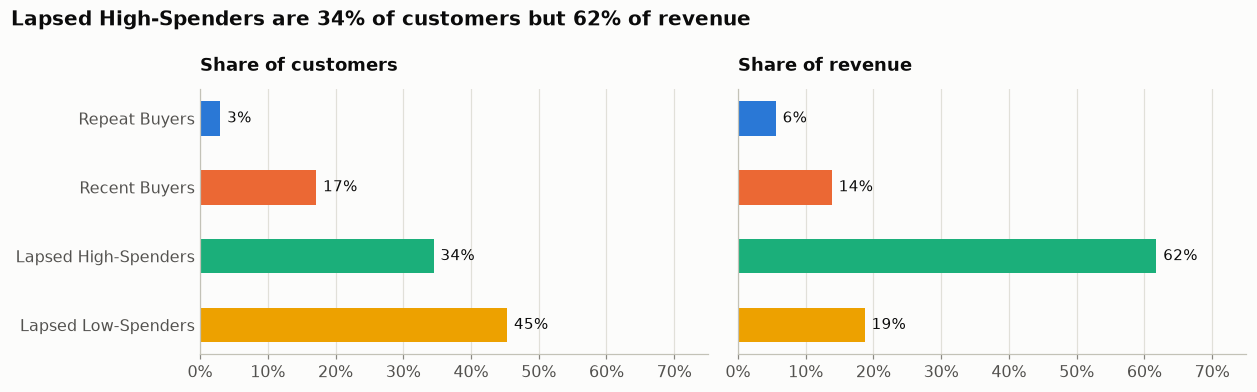

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(11.5, 3.6), sharey=True)
ylabels = SEG_ORDER[::-1]
for ax, col, title in [(axes[0], "% of customers", "Share of customers"),
                       (axes[1], "% of revenue", "Share of revenue")]:
    vals = summary.loc[ylabels, col]
    ax.barh(ylabels, vals, height=0.5, color=[SEG_COLORS[s] for s in ylabels])
    for y, v in enumerate(vals):
        ax.text(v + 1, y, f"{v:.0f}%", va="center", color=INK, fontsize=10)
    ax.set_title(title); ax.set_xlim(0, 75)
    ax.xaxis.set_major_formatter(mtick.PercentFormatter(decimals=0))
    ax.grid(axis="y", visible=False); ax.tick_params(axis="y", length=0)
hs = summary.loc["Lapsed High-Spenders"]
fig.suptitle(f"Lapsed High-Spenders are {hs['% of customers']:.0f}% of customers but {hs['% of revenue']:.0f}% of revenue",
             x=0.01, ha="left", fontsize=13, fontweight="semibold")
plt.tight_layout()
fig.savefig(FIGURES_DIR / "segment_shares.png", dpi=150, bbox_inches="tight")
plt.show()

### Snake plot

This chart shows each segment's average standardised value on each feature, with 0 representing the average customer. For Recency, **higher is worse**: it means the customer last bought longer ago.


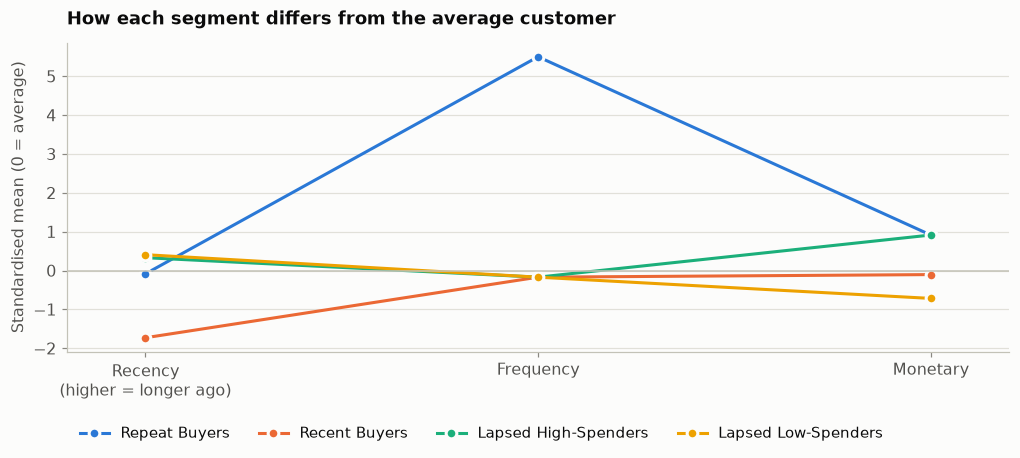

In [17]:
X_df = pd.DataFrame(X, columns=features, index=rfm.index)
snake = X_df.groupby(rfm.Segment, observed=True).mean().loc[SEG_ORDER]

fig, ax = plt.subplots(figsize=(9.5, 4.4))
xs = np.arange(len(features))
for seg in SEG_ORDER:
    ax.plot(xs, snake.loc[seg], color=SEG_COLORS[seg], marker="o", markersize=7,
            markeredgecolor=SURFACE, markeredgewidth=2, label=seg)
ax.axhline(0, color=AXIS, linewidth=1)
ax.set_xticks(xs, ["Recency\n(higher = longer ago)", "Frequency", "Monetary"])
ax.set_xlim(-0.2, 2.2)
ax.set_ylabel("Standardised mean (0 = average)")
ax.set_title("How each segment differs from the average customer")
ax.grid(axis="x", visible=False)
ax.legend(loc="upper left", bbox_to_anchor=(0, -0.2), ncol=4, fontsize=9.5)
plt.tight_layout(); plt.show()

### Where each segment sits

Each panel highlights one segment against all customers in grey. The x-axis is days since last purchase and the y-axis is total spend on a log scale.

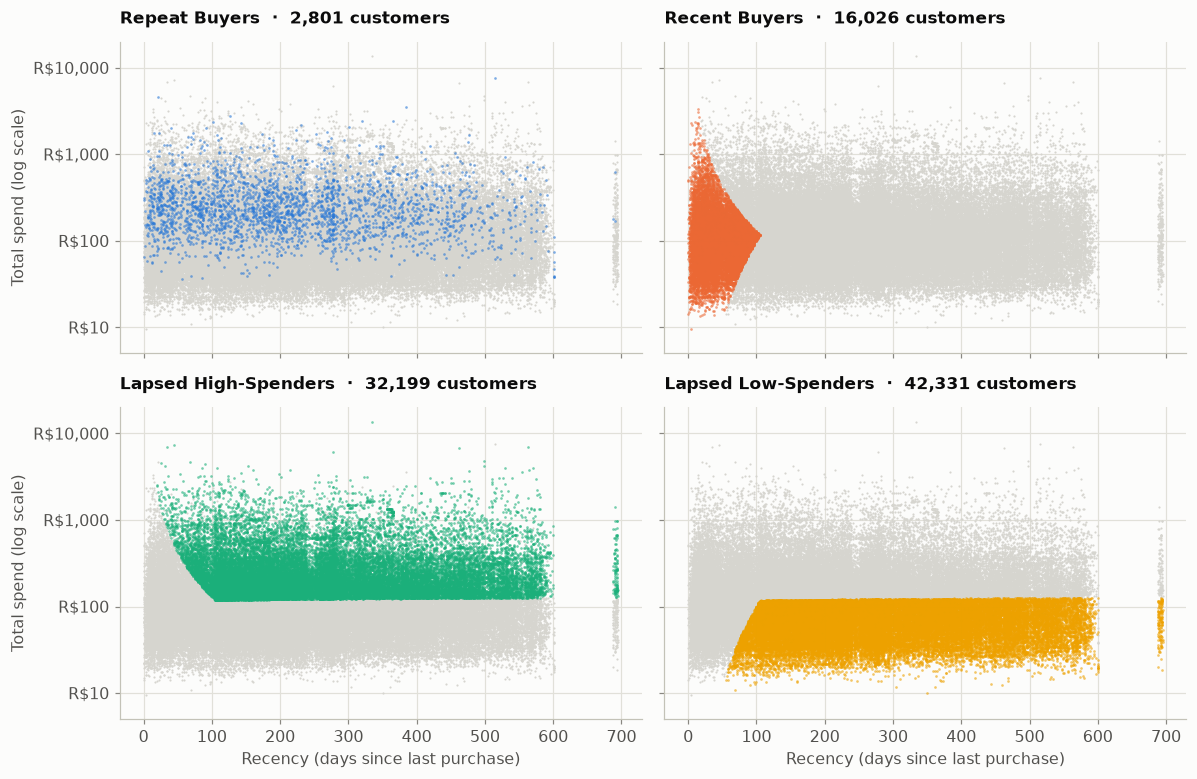

In [18]:
fig, axes = plt.subplots(2, 2, figsize=(11, 7.2), sharex=True, sharey=True)
for ax, seg in zip(axes.flat, SEG_ORDER):
    others, this = rfm[rfm.Segment != seg], rfm[rfm.Segment == seg]
    ax.scatter(others.Recency, others.Monetary, s=2, color="#d6d5cf", linewidths=0, rasterized=True)
    ax.scatter(this.Recency, this.Monetary, s=3, color=SEG_COLORS[seg], alpha=0.6, linewidths=0, rasterized=True)
    ax.set_yscale("log"); ax.set_ylim(5, 20_000)
    ax.yaxis.set_major_locator(mtick.LogLocator(base=10, numticks=6))
    ax.yaxis.set_minor_locator(mtick.NullLocator())
    ax.yaxis.set_major_formatter(mtick.FuncFormatter(brl))
    ax.set_title(f"{seg}  ·  {len(this):,} customers", fontsize=11)
for ax in axes[1]: ax.set_xlabel("Recency (days since last purchase)")
for ax in axes[:, 0]: ax.set_ylabel("Total spend (log scale)")
plt.tight_layout(); plt.show()

K-Means starts from random centroids, so we check whether the same pattern shows up with different seeds. We refit the model with five alternative random states and compare the cluster labels using the Adjusted Rand Index (ARI), where 1.0 means the grouping is effectively identical.

The ARI is at least 0.99 in every run, so the same four segments appear regardless of the starting point. The structure is stable, not just a quirk of one lucky initialisation.



In [20]:
stability = pd.Series({
    seed: adjusted_rand_score(rfm.Cluster, KMeans(n_clusters=CHOSEN_K, n_init=10, random_state=seed).fit_predict(X))
    for seed in [0, 1, 7, 21, 99]
}, name="ARI vs. final model")
stability.index.name = "random seed"
stability.round(4).to_frame()

,ARI vs. final model
random seed,
0,1.00
1,0.99
7,1.00
21,1.00
99,1.00


Beyond the RFM features, we can ask what else separates these groups. Olist's other tables tell us more about the customer journey: review score, delivery time, delays, payment method, and instalments. We attach those order-level details to each customer and compare the segments on these characteristics.



In [21]:
latest_review = (reviews.sort_values("review_answer_timestamp")
                 .drop_duplicates("order_id", keep="last")[["order_id", "review_score"]])
main_payment = (payments.sort_values("payment_value", ascending=False)
                .drop_duplicates("order_id")[["order_id", "payment_type"]])
installments = payments.groupby("order_id").payment_installments.max().rename("installments")

od = (df.merge(latest_review, on="order_id", how="left")
        .merge(main_payment, on="order_id", how="left")
        .join(installments, on="order_id")
        .join(rfm.Segment, on="customer_unique_id"))
od["delivery_days"] = (od.order_delivered_customer_date - od.order_purchase_timestamp).dt.total_seconds() / 86400
od["late"] = od.order_delivered_customer_date > od.order_estimated_delivery_date

experience = od.groupby("Segment", observed=True).agg(
    Avg_review=("review_score", "mean"),
    Pct_late=("late", lambda s: s.mean() * 100),
    Median_delivery_days=("delivery_days", "median"),
    Median_order_value=("order_value", "median"),
    Avg_installments=("installments", "mean"),
    Pct_credit_card=("payment_type", lambda s: (s == "credit_card").mean() * 100),
    Pct_boleto=("payment_type", lambda s: (s == "boleto").mean() * 100),
    Pct_Sao_Paulo=("customer_state", lambda s: (s == "SP").mean() * 100),
)
experience.round(1)

,Avg_review,Pct_late,Median_delivery_days,Median_order_value,Avg_installments,Pct_credit_card,Pct_boleto,Pct_Sao_Paulo
Segment,,,,,,,,
Repeat Buyers,4.20,7.00,10.30,100.50,3.30,75.60,18.90,43.50
Recent Buyers,4.30,6.10,7.30,103.70,2.70,75.00,18.60,46.80
Lapsed High-Spenders,4.00,9.40,12.00,199.40,4.00,79.60,17.40,36.10
Lapsed Low-Spenders,4.20,8.00,10.50,65.90,2.10,72.50,22.40,44.40


In [22]:
cat = (items.merge(products[["product_id", "product_category_name"]], on="product_id")
            .merge(cat_names, on="product_category_name", how="left")
            .merge(od[["order_id", "Segment"]], on="order_id"))
top_cats = (cat.groupby("Segment", observed=True).product_category_name_english
               .apply(lambda s: ", ".join(f"{c.replace('_', ' ')} ({p:.0%})"
                                          for c, p in s.value_counts(normalize=True).head(3).items())))
with pd.option_context("display.max_colwidth", None):
    display(top_cats.to_frame("Top 3 categories (share of items)"))

,Top 3 categories (share of items)
Segment,
Repeat Buyers,"bed bath table (15%), furniture decor (11%), sports leisure (9%)"
Recent Buyers,"health beauty (12%), bed bath table (10%), housewares (8%)"
Lapsed High-Spenders,"bed bath table (10%), sports leisure (8%), furniture decor (8%)"
Lapsed Low-Spenders,"bed bath table (10%), health beauty (9%), sports leisure (8%)"


**What stands out**

- **Lapsed High-Spenders** buy bigger-ticket items and tend to spread payment over the most instalments. This pattern is common in Brazil, and it lines up with the fact that this segment also has the slowest deliveries and the highest share of late orders.
- **Recent Buyers** have the fastest deliveries and the strongest reviews. This is consistent with Olist's improving logistics over 2018, and it also explains why health & beauty is one of their top categories.
- **Repeat Buyers** skew toward home categories such as bed/bath and furniture/decor, which are the kinds of purchases people are more likely to make more than once.
- Review scores do not vary much across the segments, and that raises an important question.

### Does a good first experience bring customers back?

If poor customer experience were the main reason people do not return, the repeat rate should rise noticeably with the first order's review score.


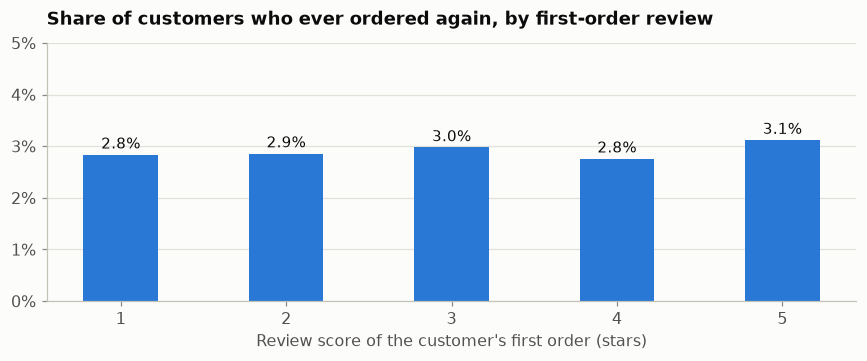

Repeat rate if first order arrived on time: 3.0%
Repeat rate if first order arrived late:    2.5%


In [23]:
first_orders = od.sort_values("order_purchase_timestamp").groupby("customer_unique_id").first()
first_orders["came_back"] = rfm.Frequency.reindex(first_orders.index) > 1
repeat_by_review = first_orders.groupby("review_score").came_back.mean() * 100

fig, ax = plt.subplots(figsize=(8, 3.4))
ax.bar(repeat_by_review.index.astype(int).astype(str), repeat_by_review.values, width=0.45, color=ACCENT)
for x, v in enumerate(repeat_by_review.values):
    ax.text(x, v + 0.12, f"{v:.1f}%", ha="center", color=INK, fontsize=10)
ax.set_ylim(0, 5); ax.yaxis.set_major_formatter(mtick.PercentFormatter(decimals=0))
ax.set_xlabel("Review score of the customer's first order (stars)")
ax.set_title("Share of customers who ever ordered again, by first-order review")
ax.grid(axis="x", visible=False)
plt.tight_layout(); plt.show()

late_repeat = first_orders.groupby("late").came_back.mean() * 100
print(f"Repeat rate if first order arrived on time: {late_repeat[False]:.1f}%")
print(f"Repeat rate if first order arrived late:    {late_repeat[True]:.1f}%")

**Customers who gave 5 stars came back only slightly more often than customers who gave 1 star.** That matters because it suggests satisfaction is not the main barrier to repeat purchases. The more likely explanation is structural: many people come to Olist to buy a specific product, not because they have developed a relationship with the marketplace. In other words, retention has to be built deliberately through post-purchase marketing rather than expected to happen automatically from a good delivery experience.


In [24]:
repeaters = df[df.customer_unique_id.isin(rfm.index[rfm.Frequency > 1])].sort_values("order_purchase_timestamp")
gap_days = repeaters.groupby("customer_unique_id").order_purchase_timestamp.apply(lambda s: (s.iloc[1] - s.iloc[0]).days)
genuine = gap_days[gap_days > 0]
print(f"Repeat buyers whose 2nd order came on the same day as the 1st: {(gap_days == 0).mean():.0%}")
print(f"Genuine returns (2nd order on a later day):                    {len(genuine):,}")
print(f"  median days from 1st to 2nd order:                           {genuine.median():.0f}")
print(f"  middle 50% of returns come after:                            {genuine.quantile(0.25):.0f}–{genuine.quantile(0.75):.0f} days")
print(f"  share returning within 60 days:                              {(genuine <= 60).mean():.0%}")

shopping_days = df.assign(day=df.order_purchase_timestamp.dt.date).groupby("customer_unique_id").day.nunique()
print(f"\nRepeat customers counted by distinct shopping days instead of orders: "
      f"{(shopping_days > 1).sum():,} ({(shopping_days > 1).mean():.1%})")

Repeat buyers whose 2nd order came on the same day as the 1st: 30%
Genuine returns (2nd order on a later day):                    1,948
  median days from 1st to 2nd order:                           76
  middle 50% of returns come after:                            24–179 days
  share returning within 60 days:                              44%

Repeat customers counted by distinct shopping days instead of orders: 2,015 (2.2%)


Almost a third of customers counted as repeat buyers actually placed their second order on the **same day** as the first. That usually reflects a single shopping session split into multiple orders, for example when items come from different sellers. When we count distinct shopping days instead, only about 2% of customers truly came back.

Among genuine repeat buyers, the second order arrives after a **median of about 2½ months**, and fewer than half are placed within 60 days. That suggests a post-purchase campaign should run over the first few months, not just the first week.

## 13. Segment profiles and recommendations


In [25]:
for seg in SEG_ORDER:
    s, e = summary.loc[seg], experience.loc[seg]
    print(f"{seg}: {s.Customers:,.0f} customers ({s['% of customers']:.0f}%) · {s['% of revenue']:.0f}% of revenue · "
          f"last bought ~{s.Median_recency_days:.0f} days ago · median spend R${s.Median_spend:,.0f} · "
          f"avg review {e.Avg_review:.2f} · avg instalments {e.Avg_installments:.1f}")

Repeat Buyers: 2,801 customers (3%) · 6% of revenue · last bought ~199 days ago · median spend R$226 · avg review 4.20 · avg instalments 3.3
Recent Buyers: 16,026 customers (17%) · 14% of revenue · last bought ~37 days ago · median spend R$104 · avg review 4.31 · avg instalments 2.7
Lapsed High-Spenders: 32,199 customers (34%) · 62% of revenue · last bought ~254 days ago · median spend R$199 · avg review 4.03 · avg instalments 4.0
Lapsed Low-Spenders: 42,331 customers (45%) · 19% of revenue · last bought ~269 days ago · median spend R$66 · avg review 4.16 · avg instalments 2.1


| Segment | Who they are | Goal | Recommended actions |
|---|---|---|---|
| **Repeat Buyers** | The ~3% of customers who ordered more than once. They spend the most per customer and skew toward home and furniture categories. | **Reward and learn from them** | Offer loyalty perks and early access to sales, add referral incentives, and study their first purchases to identify the products that actually lead to a second order. |
| **Recent Buyers** | Customers with a single order placed very recently, usually within the last few weeks. They also have the fastest deliveries and the strongest reviews. | **Win the second order** | Run a short post-purchase sequence over the next few months: thank-you message, review request, then category-based cross-sells and a second-order voucher. Genuine second orders take a median of ~2½ months, so the campaign should last longer than a single email. |
| **Lapsed High-Spenders** | One-time buyers who bought a larger ticket item and have been inactive for around 8 months. They generate most of the revenue. | **Win back with the right offer** | Focus on complementary products, instalment-friendly offers, and more careful delivery promises. This group also shows the highest share of late deliveries, so reassurance matters. |
| **Lapsed Low-Spenders** | One-time buyers with small baskets and a long inactivity gap of about 9 months. They are the largest group by volume, but contribute the least value. | **Automate, don't overspend** | Keep the message low-cost: trigger automated emails around major sale moments and move non-responders into a low-cost retention list rather than spending heavily on each customer. |

## 14. Save the results


In [26]:
out = rfm.reset_index()[["customer_unique_id", "Segment", "Recency", "Frequency", "Monetary"]]
out.to_csv(OUTPUT_DIR / "customer_segments.csv", index=False)
print(f"Saved {len(out):,} customers to outputs/customer_segments.csv")
out.head()

Saved 93,357 customers to outputs/customer_segments.csv


,customer_unique_id,Segment,Recency,Frequency,Monetary
0,0000366f3b9a7992bf8c76cfdf3221e2,Lapsed High-Spenders,111,1,141.90
1,0000b849f77a49e4a4ce2b2a4ca5be3f,Lapsed Low-Spenders,114,1,27.19
2,0000f46a3911fa3c0805444483337064,Lapsed Low-Spenders,537,1,86.22
3,0000f6ccb0745a6a4b88665a16c9f078,Lapsed Low-Spenders,321,1,43.62
4,0004aac84e0df4da2b147fca70cf8255,Lapsed High-Spenders,288,1,196.89


## Conclusions

- **93,357 customers** were segmented using RFM features, a log transform, standardisation and K-Means with k = 4. The resulting clusters are highly stable, with an ARI of at least 0.99 across different random seeds.
- **97% of Olist customers bought only once.** K-Means isolates the small repeat-buyer minority as its own segment and then separates the remaining one-time buyers by recency and spend.
- **Lapsed High-Spenders are about a third of customers but contribute about 62% of revenue.** Win-back campaigns aimed at this group offer the clearest revenue opportunity.
- **Retention is not automatic.** Repeat rates remain close to 3% whether the first order gets 1 star or 5, which shows that a good first experience is not enough on its own. The business needs active post-purchase marketing to turn one-time buyers into repeat customers.

## Limitations and next steps

- **Frequency barely varies.** With 97% of customers tied at one order, RFM here is effectively “RM plus a repeat flag”. Additional features such as category mix, instalment use, basket size, or state could produce richer customer segments.
- **Split orders inflate repeat buying.** Counting distinct shopping days instead of orders gives a stricter definition of a repeat customer, which suggests the true return rate is closer to 2% than 3%.
- **The time window is short and uneven.** The data ends in August 2018, and customers from 2016 naturally appear very inactive simply because they are older in the dataset.
- **Next steps:** predict which Recent Buyers are most likely to make a second purchase with a classification model, or estimate lifetime value with BG/NBD and Gamma-Gamma models.
